# **RANDOM FOREST FEATURE IMPORTANCE**

GitHub - https://github.com/Manasa-2409/machine-learning-/tree/main

#### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
sns.set_palette("colorblind")

plt.rcParams["figure.figsize"] = (10,6)

### Load Titanic Dataset

In [ ]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Handle missing values

In [ ]:
df["age"].fillna(df["age"].median(), inplace=True)

df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

/tmp/ipykernel_195/1782511801.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


### Encode Categorical Variables

In [ ]:
df = pd.get_dummies(df, drop_first=True)

### Survival Distribution Plot

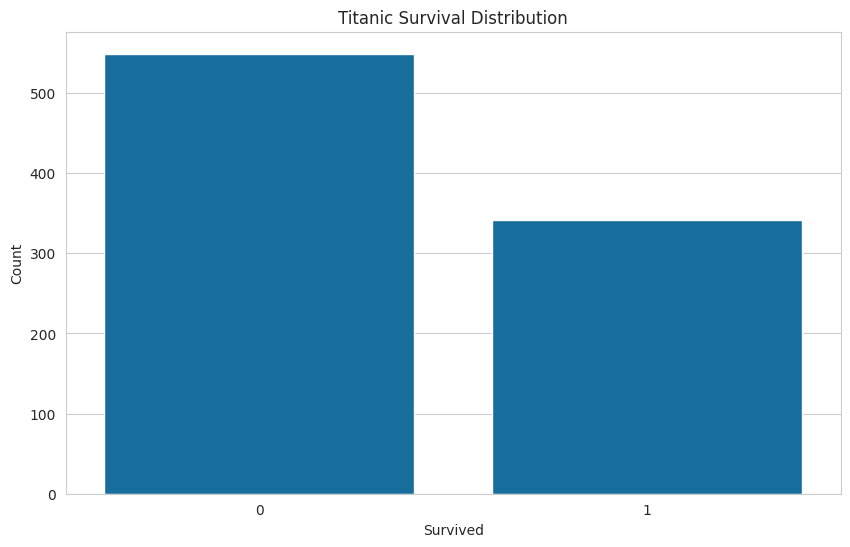

In [ ]:
sns.countplot(x="survived", data=df)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.savefig("figure1_survival_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
X = df.drop("survived", axis=1)

y = df["survived"]

### Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train Random Forest Model

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### Model Accuracy

In [ ]:
preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8100558659217877


### Extract Random Forest Feature Importance

In [ ]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
4,fare,0.272564
5,sex_male,0.270008
1,age,0.253504
0,pclass,0.083473
2,sibsp,0.050061
3,parch,0.037864
7,embarked_S,0.022906
6,embarked_Q,0.009621


### Plot Random Forest Feature Importance

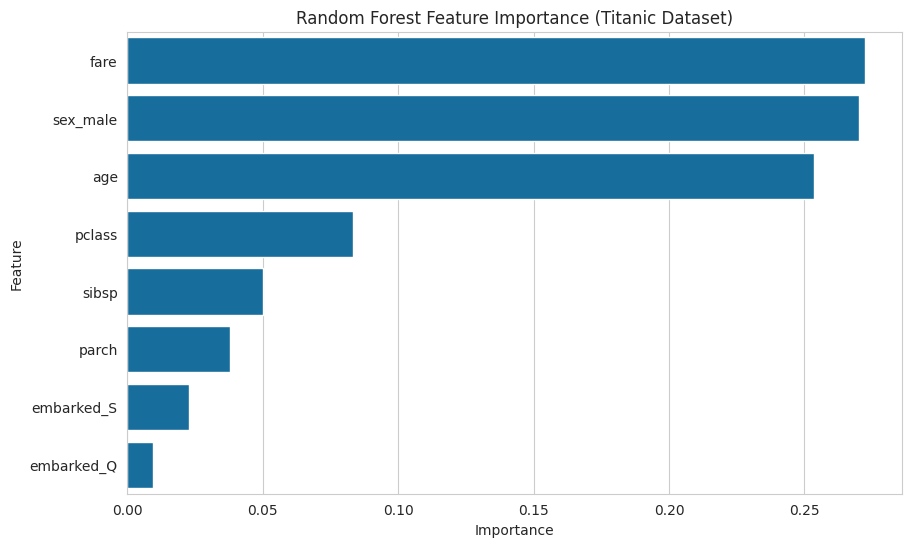

In [ ]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance (Titanic Dataset)")

plt.savefig("figure2_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Permutation Feature Importance

In [ ]:
perm_importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df

,Feature,Importance
5,sex_male,0.167039
0,pclass,0.053631
4,fare,0.044134
7,embarked_S,0.029050
1,age,0.018994
2,sibsp,0.015642
3,parch,0.005028
6,embarked_Q,-0.003352


### Plot for Permutation Importance

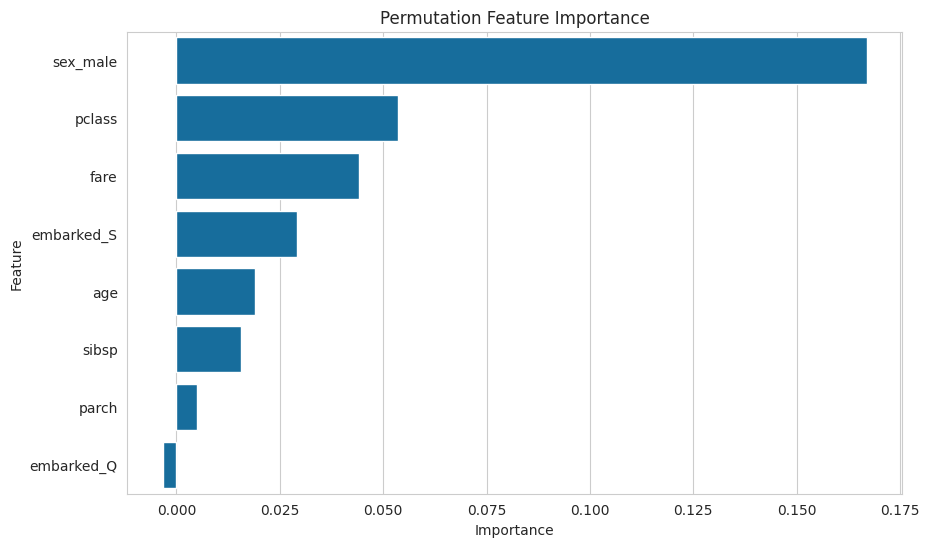

In [ ]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=perm_df
)

plt.title("Permutation Feature Importance")

plt.savefig("figure3_permutation_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### Comparision models

In [ ]:
comparison_df = importance_df.merge(
    perm_df,
    on="Feature",
    suffixes=("_RF", "_Permutation")
)

comparison_df

,Feature,Importance_RF,Importance_Permutation
0,fare,0.272564,0.044134
1,sex_male,0.270008,0.167039
2,age,0.253504,0.018994
3,pclass,0.083473,0.053631
4,sibsp,0.050061,0.015642
5,parch,0.037864,0.005028
6,embarked_S,0.022906,0.029050
7,embarked_Q,0.009621,-0.003352


### Plot Importance Comparison

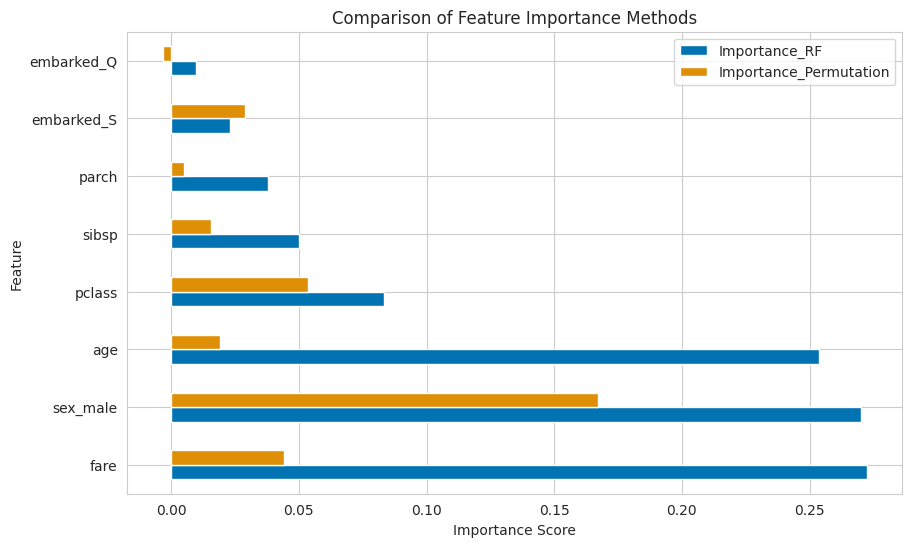

In [ ]:
comparison_df.set_index("Feature")[[
    "Importance_RF",
    "Importance_Permutation"
]].plot(
    kind="barh"
)

plt.title("Comparison of Feature Importance Methods")

plt.xlabel("Importance Score")

plt.savefig("figure4_importance_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### Confusion Matrix

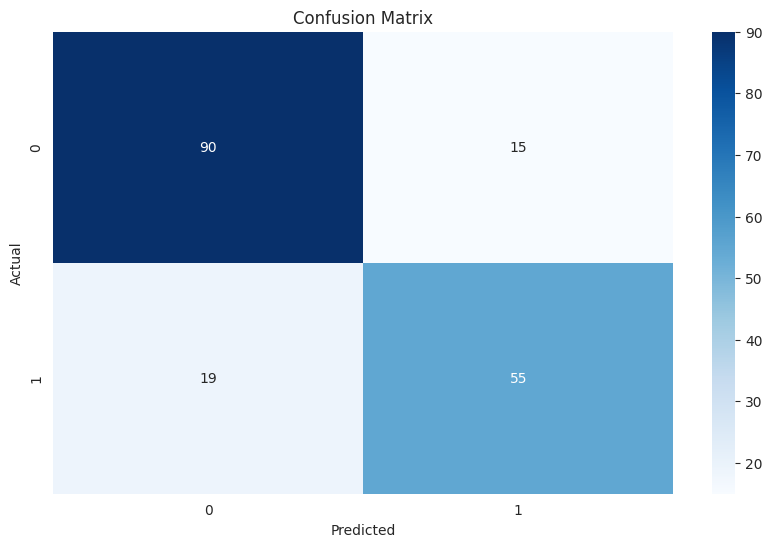

In [ ]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("figure5_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Classification report

In [ ]:
print(classification_report(
    y_test,
    preds,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

